# 2장 실습 — 액션이라는 말 안에 든 선택들

**대응 이론** 2장 「로봇 행동의 표현」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 4분)

1장에서 지각부터 액션까지 하나로 잇겠다고 했다. 그러면 그 망이 **무엇을 출력해야 하는가**.

「액션」이라는 한 단어 안에 최소한 네 개의 선택이 숨어 있다. 어느 좌표계로 쓸 것인가, 절대값인가 변화량인가, 회전을 어떻게 적을 것인가, 축마다 다른 스케일을 어떻게 맞출 것인가. 이 선택들은 모델 구조나 데이터보다 **먼저** 정해지고, 잘못 고르면 뒤에서 무엇을 해도 회복되지 않는다.

이 노트북에서 그 네 가지를 각각 잰다. 첫 번째와 세 번째에서 **수십 배에서 수백 배**의 차이가 나온다.

1. 좌표계 — 관절인가 말단인가
2. 절대인가 변화량인가
3. 회전을 적는 법
4. 축마다 다른 스케일

In [3]:
%matplotlib inline
import os, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__)

torch 2.9.1


In [4]:
class Net(nn.Module):
    def __init__(s, i, o, h=128):
        super().__init__()
        s.f = nn.Sequential(
            nn.Linear(i, h), 
            nn.GELU(), 
            nn.Linear(h, h), 
            nn.GELU(), 
            nn.Linear(h, o)
        )
    def forward(s, x): return s.f(x)

def fit(X, Y, steps=2500, lr=2e-3, seed=0, h=128):
    torch.manual_seed(seed); m = Net(X.shape[1], Y.shape[1], h)
    opt = torch.optim.AdamW(m.parameters(), lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(1)
    for i in range(steps):
        idx = torch.randint(0, len(X), (256,), generator=g)
        loss = F.smooth_l1_loss(m(X[idx]), Y[idx], beta=.05)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m

## 1. 좌표계 — 관절인가 말단인가

팔꿈치 하나짜리 2링크 평면 팔을 쓴다. 과제는 「목표 지점으로 말단을 보내라」이고, 같은 과제를 두 가지 출력으로 배운다.

- **관절 공간** — 목표 위치를 받아 관절 각도 (q₁, q₂) 를 낸다
- **말단 공간** — 현재 위치와 목표를 받아 위치 변화량 (Δx, Δy) 를 낸다

두 조건에서 각각 잰다. 시연이 **한 자세로 통일된** 경우와, 팔꿈치를 위로 꺾은 시연과 아래로 꺾은 시연이 **섞인** 경우다.

  시연                                 관절 공간       말단 공간       배율
  --------------------------------------------------------------
  한 자세로 통일 (팔꿈치 위)                  0.1059      0.0011      98배
  두 자세가 섞임                          1.0029      0.0011     928배


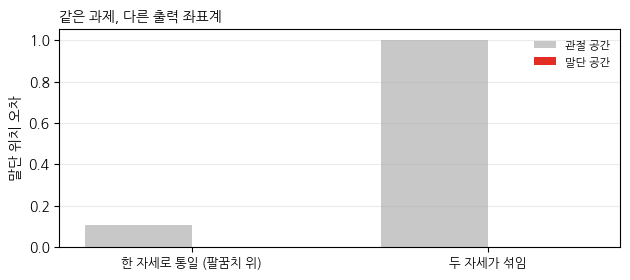

  두 자세가 섞임                          1.0029      0.0011     928배


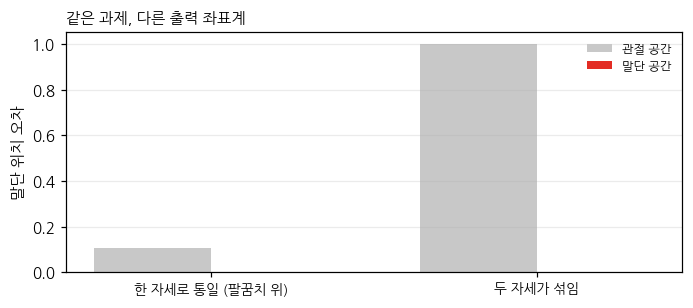

In [5]:
L1 = L2 = 1.0
def fk(q):
    return np.stack([L1*np.cos(q[:, 0]) + L2*np.cos(q[:, 0] + q[:, 1]),
                     L1*np.sin(q[:, 0]) + L2*np.sin(q[:, 0] + q[:, 1])], 1)

def arm(n, seed, elbow="up"):
    r = np.random.default_rng(seed)
    q1 = r.uniform(-np.pi, np.pi, n); q2 = r.uniform(0.25, 2.6, n)     # 팔꿈치 위
    if elbow == "both":
        q2 = np.where(r.random(n) < .5, -q2, q2)                        # 위/아래 섞기
    q = np.stack([q1, q2], 1).astype(np.float32); p = fk(q).astype(np.float32)
    keep = (np.linalg.norm(p, axis=1) > .4) & (np.linalg.norm(p, axis=1) < 1.8)
    return q[keep], p[keep]

print(f"  {'시연':<28}{'관절 공간':>12}{'말단 공간':>12}{'배율':>9}")
print("  " + "-" * 62)
bars = {}
for elbow, lbl in [("up", "한 자세로 통일 (팔꿈치 위)"), ("both", "두 자세가 섞임")]:
    qtr, ptr = arm(9000, 0, elbow); qte, pte = arm(3000, 7, elbow)
    m = fit(torch.tensor(ptr), torch.tensor(qtr))                       # 목표 → 관절각
    with torch.no_grad(): qp = m(torch.tensor(pte)).numpy()
    e_joint = np.linalg.norm(fk(qp) - pte, axis=1).mean()
    perm = np.random.default_rng(5).permutation(len(ptr))
    m2 = fit(torch.tensor(np.concatenate([ptr[perm], ptr], 1)), torch.tensor(ptr - ptr[perm]))
    cur = pte[np.random.default_rng(6).permutation(len(pte))]
    with torch.no_grad(): d = m2(torch.tensor(np.concatenate([cur, pte], 1))).numpy()
    e_ee = np.linalg.norm(cur + d - pte, axis=1).mean()
    bars[lbl] = (e_joint, e_ee)
    print(f"  {lbl:<28}{e_joint:>12.4f}{e_ee:>12.4f}{e_joint/e_ee:>8.0f}배")

fig, ax = plt.subplots(figsize=(6.4, 2.9))
x = np.arange(2); w = .36
ax.bar(x - w/2, [v[0] for v in bars.values()], w, color=GREY, label="관절 공간")
ax.bar(x + w/2, [v[1] for v in bars.values()], w, color=RED, label="말단 공간")
ax.set_xticks(x); ax.set_xticklabels(list(bars), fontsize=9)
ax.set_ylabel("말단 위치 오차"); ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25, axis="y")
ax.set_title("같은 과제, 다른 출력 좌표계", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 2. 절대인가 변화량인가

두 번째 선택. 「목표는 (0.3, 0.5) 다」와 「여기서 (0.1, −0.2) 만큼 가라」 중 무엇을 출력할 것인가.

흔한 답은 「델타가 일반화에 좋다」인데, 그 말이 정확히 무엇을 뜻하는지 재 본다. 원점 주변에서만 학습하고, **작업 영역을 옮겨서** 평가한다.

  학습은 원점 주변에서만. 그 뒤 작업 영역을 옮겨 평가한다

  구성                            같은 영역    +1.2 이동      +3 이동
  ----------------------------------------------------------
  절대 입력 → 절대 출력                0.0003     0.0304     0.3265
  절대 입력 → 델타 출력                0.0003     0.0165     0.2470
  상대 입력 → 델타 출력                0.0003     0.0003     0.0003


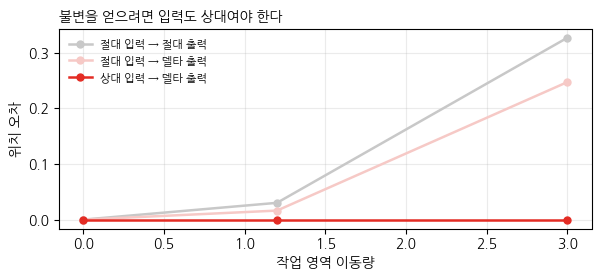

  절대 입력 → 델타 출력                0.0003     0.0165     0.2470


  상대 입력 → 델타 출력                0.0003     0.0003     0.0003


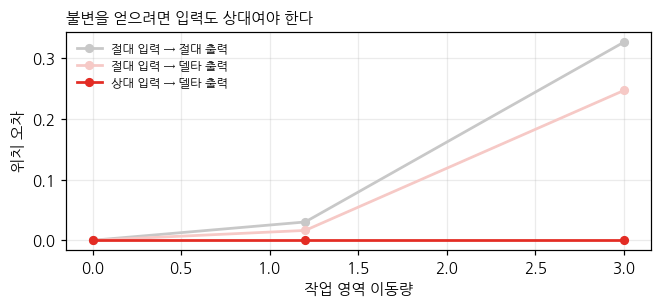

In [6]:
def mk(n, shift, seed):
    r = np.random.default_rng(seed)
    cur = (r.uniform(-.6, .6, (n, 2)) + shift).astype(np.float32)
    tgt = (cur + r.uniform(-.3, .3, (n, 2))).astype(np.float32)
    return cur, tgt

cur, tgt = mk(9000, np.float32([0, 0]), 0)
cfg = [("절대 입력 → 절대 출력", lambda c, t: np.concatenate([c, t], 1), lambda c, o: o,     lambda c, t: t),
       ("절대 입력 → 델타 출력", lambda c, t: np.concatenate([c, t], 1), lambda c, o: c + o, lambda c, t: t - c),
       ("상대 입력 → 델타 출력", lambda c, t: t - c,                     lambda c, o: c + o, lambda c, t: t - c)]
shifts = [0.0, 1.2, 3.0]
print("  학습은 원점 주변에서만. 그 뒤 작업 영역을 옮겨 평가한다")
print(f"\n  {'구성':<24}" + "".join(f"{f'+{s:g} 이동' if s else '같은 영역':>11}" for s in shifts))
print("  " + "-" * 58)
rows = {}
for name, fx, fo, fy in cfg:
    m = fit(torch.tensor(fx(cur, tgt)), torch.tensor(fy(cur, tgt)))
    row = []
    for sh in shifts:
        c2, t2 = mk(2000, np.float32([sh, sh]), 9)
        with torch.no_grad(): o = m(torch.tensor(fx(c2, t2))).numpy()
        row.append(np.linalg.norm(fo(c2, o) - t2, axis=1).mean())
    rows[name] = row
    print(f"  {name:<24}" + "".join(f"{v:>11.4f}" for v in row))

fig, ax = plt.subplots(figsize=(6.2, 2.9))
for (n_, r_), c in zip(rows.items(), [GREY, PINK, RED]):
    ax.plot(shifts, r_, "o-", color=c, lw=1.8, ms=5, label=n_)
ax.set_xlabel("작업 영역 이동량"); ax.set_ylabel("위치 오차")
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25)
ax.set_title("불변을 얻으려면 입력도 상대여야 한다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 3. 회전을 적는 법

세 번째 선택은 덜 알려져 있고 영향이 가장 크다. 6자유도 팔의 액션에는 회전이 들어가는데, **회전을 숫자로 적는 방법이 여럿**이고 그 선택이 학습 난이도를 크게 바꾼다.

같은 회전을 세 가지로 표현해 예측해 본다. 입력은 회전행렬 9개 숫자이고, 출력만 바꾼다.

- **오일러각** (3차원) — roll, pitch, yaw
- **쿼터니언** (4차원) — 단위 사원수
- **6D** (6차원) — 회전행렬의 앞 두 열, 그람-슈미트로 복원

평가는 표현과 무관한 **측지 오차**(두 회전 사이의 실제 각도)로 한다.

  표현              출력 차원       중앙값        평균      90분위
  -----------------------------------------------------
  오일러각                3     1.72°    17.66°    69.64°
  쿼터니언                4     1.06°     3.26°     3.37°
  6D                  6     0.05°     0.05°     0.08°


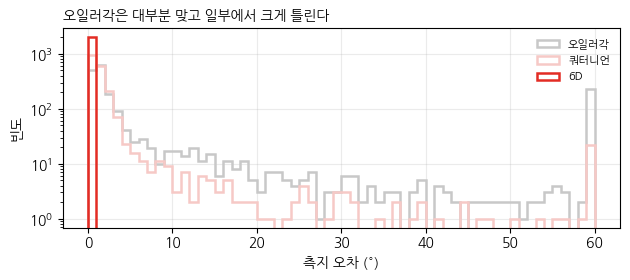

  쿼터니언                4     1.06°     3.26°     3.37°


  6D                  6     0.05°     0.05°     0.08°


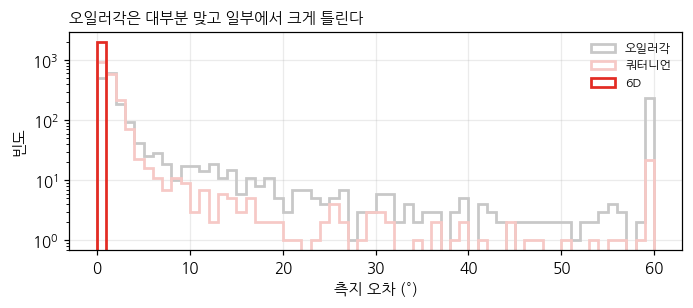

In [7]:
def rand_rot(n, rng):
    q = rng.normal(size=(n, 4)); q /= np.linalg.norm(q, axis=1, keepdims=True)
    w, x, y, z = q.T
    return np.stack([1-2*(y*y+z*z), 2*(x*y-w*z), 2*(x*z+w*y),
                     2*(x*y+w*z), 1-2*(x*x+z*z), 2*(y*z-w*x),
                     2*(x*z-w*y), 2*(y*z+w*x), 1-2*(x*x+y*y)], 1).reshape(n, 3, 3).astype(np.float32)

def to_euler(R):
    sy = np.sqrt(R[:, 0, 0]**2 + R[:, 1, 0]**2)
    return np.stack([np.arctan2(R[:, 2, 1], R[:, 2, 2]), np.arctan2(-R[:, 2, 0], sy),
                     np.arctan2(R[:, 1, 0], R[:, 0, 0])], 1).astype(np.float32)
def to_quat(R):
    w = np.sqrt(np.clip(1 + R[:, 0, 0] + R[:, 1, 1] + R[:, 2, 2], 1e-8, None)) / 2
    q = np.stack([w, (R[:,2,1]-R[:,1,2])/(4*w), (R[:,0,2]-R[:,2,0])/(4*w), (R[:,1,0]-R[:,0,1])/(4*w)], 1)
    q *= np.sign(q[:, :1] + 1e-12)                                 # 반구 고정
    return (q / np.linalg.norm(q, axis=1, keepdims=True)).astype(np.float32)
def to_6d(R): return R[:, :, :2].transpose(0, 2, 1).reshape(len(R), 6).astype(np.float32)

def from_6d(v):
    e1 = F.normalize(v[:, :3], dim=1)
    e2 = F.normalize(v[:, 3:] - (e1*v[:, 3:]).sum(1, keepdim=True)*e1, dim=1)
    return torch.stack([e1, e2, torch.cross(e1, e2, dim=1)], 2)
def from_quat(q):
    q = F.normalize(q, dim=1); w, x, y, z = q.unbind(1)
    return torch.stack([1-2*(y*y+z*z), 2*(x*y-w*z), 2*(x*z+w*y),
                        2*(x*y+w*z), 1-2*(x*x+z*z), 2*(y*z-w*x),
                        2*(x*z-w*y), 2*(y*z+w*x), 1-2*(x*x+y*y)], 1).reshape(-1, 3, 3)
def from_euler(e):
    cr, sr = torch.cos(e[:,0]), torch.sin(e[:,0]); cp, sp = torch.cos(e[:,1]), torch.sin(e[:,1])
    cy, sy = torch.cos(e[:,2]), torch.sin(e[:,2])
    return torch.stack([cy*cp, cy*sp*sr-sy*cr, cy*sp*cr+sy*sr,
                        sy*cp, sy*sp*sr+cy*cr, sy*sp*cr-cy*sr,
                        -sp,   cp*sr,          cp*cr], 1).reshape(-1, 3, 3)

Rtr = rand_rot(8000, np.random.default_rng(0)); Rte = rand_rot(2000, np.random.default_rng(1))
def geo_err(Rp, Rt):
    tr = (Rp.transpose(1, 2) @ Rt).diagonal(dim1=1, dim2=2).sum(1)
    return torch.rad2deg(torch.acos(((tr - 1) / 2).clamp(-1, 1)))

errs = {}
print(f"  {'표현':<12}{'출력 차원':>9}{'중앙값':>10}{'평균':>10}{'90분위':>10}")
print("  " + "-" * 53)
for name, tf, od, dec in [("오일러각", to_euler, 3, from_euler), ("쿼터니언", to_quat, 4, from_quat), ("6D", to_6d, 6, from_6d)]:
    m = fit(torch.tensor(Rtr.reshape(-1, 9)), torch.tensor(tf(Rtr)), steps=3000, lr=1e-3, h=256)
    with torch.no_grad(): e = geo_err(dec(m(torch.tensor(Rte.reshape(-1, 9)))), torch.tensor(Rte))
    errs[name] = e.numpy()
    print(f"  {name:<12}{od:>9}{e.median():>9.2f}°{e.mean():>9.2f}°{e.quantile(.9):>9.2f}°")

fig, ax = plt.subplots(figsize=(6.4, 2.9))
for (n_, e_), c in zip(errs.items(), [GREY, PINK, RED]):
    ax.hist(np.clip(e_, 0, 60), bins=60, range=(0, 60), histtype="step", lw=1.8, color=c, label=n_)
ax.set_xlabel("측지 오차 (°)"); ax.set_ylabel("빈도"); ax.set_yscale("log")
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25)
ax.set_title("오일러각은 대부분 맞고 일부에서 크게 틀린다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 4. 축마다 다른 스케일

마지막 선택. 7차원 액션의 축들은 물리 단위가 다르다. 이동은 미터, 회전은 라디안, 그리퍼는 열림 폭이다. 값의 범위가 축마다 열 배, 백 배 차이 날 수 있다.

정규화 없이 학습하면 무슨 일이 생기는지 본다.

  축별 정답 표준편차: ['0.579', '0.572', '28.783', '0.012']

                          축0        축1        축2        축3
  --------------------------------------------------------
  정규화 없음              0.007    0.007    0.001    0.109


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

  축별 정규화              0.001    0.001    0.001    0.001

  (값은 각 축의 표준편차 대비 평균 오차 — 작을수록 좋다)


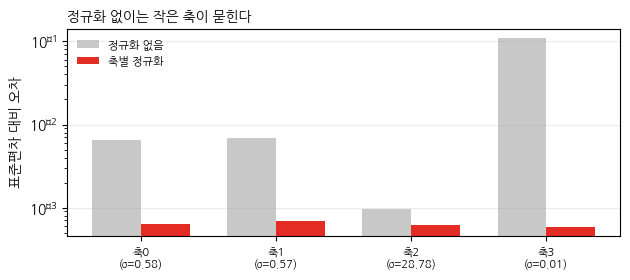

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


  축별 정규화              0.001    0.001    0.001    0.001

  (값은 각 축의 표준편차 대비 평균 오차 — 작을수록 좋다)


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


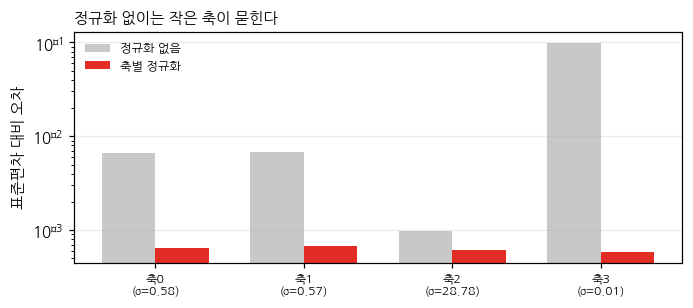

In [8]:
r = np.random.default_rng(0)
N = 9000
base = r.uniform(-1, 1, (N, 4)).astype(np.float32)
SCALE = np.float32([1.0, 1.0, 50.0, 0.02])            # 축마다 다른 물리 단위
X = torch.tensor(base)
Yraw = torch.tensor(base * SCALE)
mu, sd = Yraw.mean(0), Yraw.std(0)

print(f"  축별 정답 표준편차: {[f'{v:.3f}' for v in sd.tolist()]}")
print(f"\n  {'':<16}" + "".join(f"{f'축{i}':>10}" for i in range(4)))
print("  " + "-" * 56)
res = {}
for tag, Y in [("정규화 없음", Yraw), ("축별 정규화", (Yraw - mu) / sd)]:
    m = fit(X, Y, steps=2500)
    with torch.no_grad(): p = m(X)
    if tag != "정규화 없음": p = p * sd + mu
    rel = ((p - Yraw).abs().mean(0) / sd).numpy()      # 축별 상대 오차
    res[tag] = rel
    print(f"  {tag:<16}" + "".join(f"{v:>9.3f}" for v in rel))
print("\n  (값은 각 축의 표준편차 대비 평균 오차 — 작을수록 좋다)")

fig, ax = plt.subplots(figsize=(6.4, 2.9))
x = np.arange(4); w = .36
ax.bar(x - w/2, res["정규화 없음"], w, color=GREY, label="정규화 없음")
ax.bar(x + w/2, res["축별 정규화"], w, color=RED, label="축별 정규화")
ax.set_xticks(x); ax.set_xticklabels([f"축{i}\n(σ={sd[i]:.2f})" for i in range(4)], fontsize=8)
ax.set_ylabel("표준편차 대비 오차"); ax.set_yscale("log")
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25, axis="y")
ax.set_title("정규화 없이는 작은 축이 묻힌다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

### 다음 장으로
다음 장에서는 VLA 이전에 이 문제들을 어떻게 풀었는지 본다. ACT 와 Diffusion Policy 가 무엇을 해결했고, VLA 가 그중 무엇을 물려받았는지가 3장의 주제다.